## Diabetes Prediction Model Analysis

### Table of Contents
- [Diabetes Prediction Model Analysis](#diabetes-prediction-model-analysis)
  - [Intro](#intro)
  - [Data Loading and Cleaning](#data-loading-and-cleaning)
  - [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
  - [Feature Selection](#feature-selection)
  - [Logistic Regression Modeling](#logistic-regression-modeling)
  - [Interpreting Logistic Regression Coefficients](#interpreting-logistic-regression-coefficients)
  - [Logistic Regression Performance](#logistic-regression-performance)
  - [Random Forest Modeling](#random-forest-modeling)
  - [ROC Curve Comparison](#roc-curve-comparison)
  - [Model Evaluation Summary](#model-evaluation-summary)

### Intro

This project explores whether lifestyle factors specifically diet quality and weekly physical activity can help predict whether an individual has been diagnosed with diabetes. Using a real-world diabetes dataset, the analysis applies multiple machine learning models, including Logistic Regression and Random Forest, to evaluate how strongly these two variables contribute to diabetes risk. The goal of this project is not only to test prediction accuracy but also to understand the direction and magnitude of the relationship between lifestyle behaviors and diabetes outcomes.

### Data Loading and Cleaning

In [48]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import PercentFormatter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

In [49]:
# Used to annotate the numeric value of a bar chart
def annotate_bars(ax, fmt="{:.0f}"):
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            fmt.format(height),
            (p.get_x() + p.get_width() / 2, height),
            ha='center', va='bottom', fontsize=10
        )

In [50]:
# Reads the CSV file and links it diabetes variable
df = pd.read_csv("diabetes_dataset.csv")

Lets see what variables this dataset has to offer

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

Visual look at first 5 rows of data

In [52]:
df.head(5)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


Look at the data distribution

In [53]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


Look to see if there are any null values in each column

In [54]:
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


### Exploratory Data Analysis (EDA) 

Here we explore the distribution of key variables such as age, gender, diabetes diagnosis, smoking status, and alcohol consumption.
Bar charts and summary statistics help highlight trends in the population. For example, the diabetes diagnosis distribution reveals whether the dataset is balanced or imbalanced.

Additionally, we compare average diet score and average physical activity levels between individuals with and without diabetes. 
These insights help determine whether lifestyle factors differ meaningfully between the two groups before applying machine learning models.

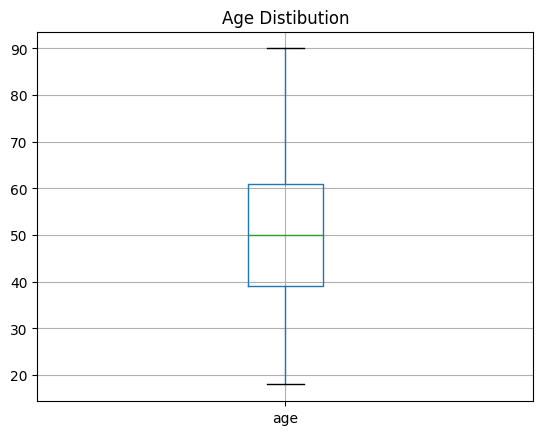

In [55]:
df.boxplot(column='age') 
plt.title('Age Distibution') 
plt.show()

In [56]:
df['gender'].value_counts()

gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64

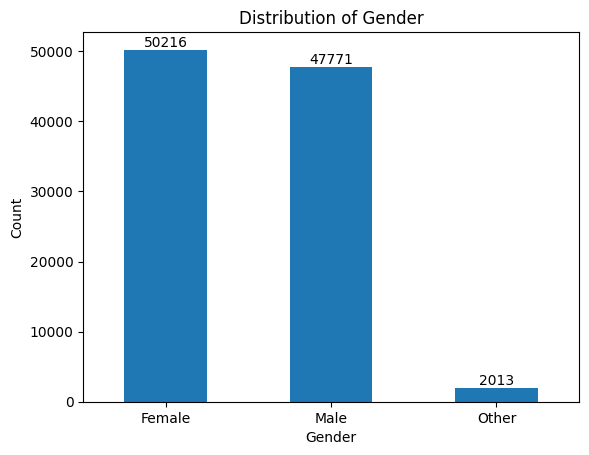

In [57]:
ax = df['gender'].value_counts().plot(kind='bar')

plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.xticks(rotation=0)

annotate_bars(ax)

plt.show()

In [58]:
df['diagnosed_diabetes'].value_counts()

diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64

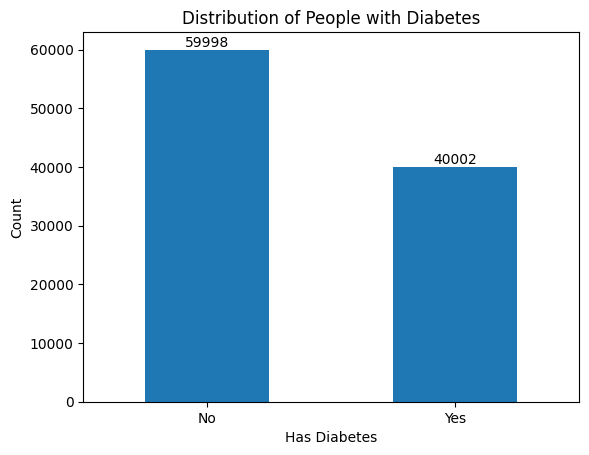

In [59]:
ax = df['diagnosed_diabetes'].value_counts().plot(kind='bar')

plt.xlabel('Has Diabetes')
plt.ylabel('Count')
plt.title('Distribution of People with Diabetes')
plt.xticks([1,0],['Yes','No'], rotation = 0)

annotate_bars(ax)

plt.show()

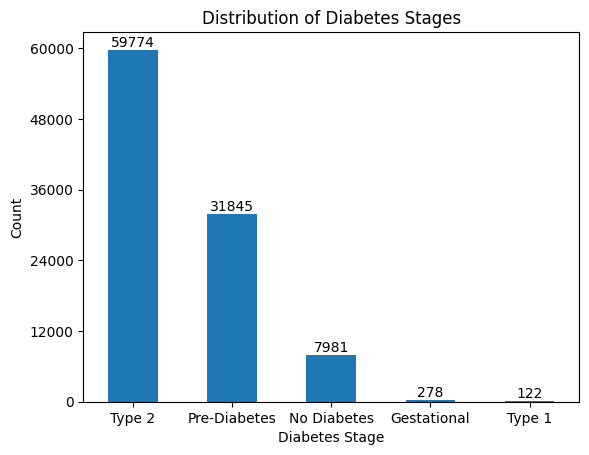

In [60]:
ax = df['diabetes_stage'].value_counts().plot(kind='bar')

plt.xlabel('Diabetes Stage')
plt.ylabel('Count')
plt.title('Distribution of Diabetes Stages')
plt.xticks(rotation = 0)

annotate_bars(ax)

ax.yaxis.set_major_locator(MultipleLocator(12000))

plt.show()

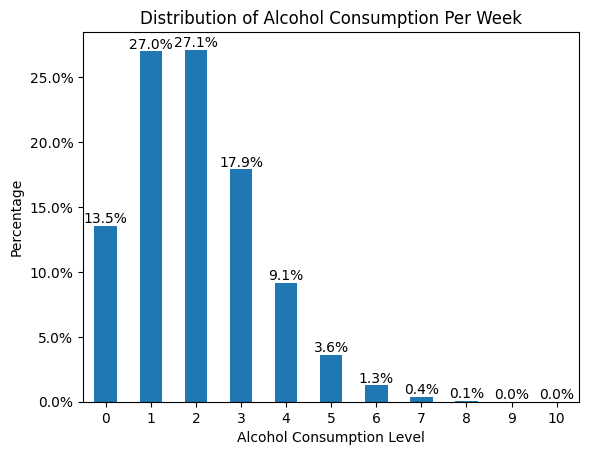

In [61]:
ax = df['alcohol_consumption_per_week'].value_counts(normalize=True).sort_index().plot(kind='bar')

plt.xlabel('Alcohol Consumption Level')
plt.ylabel('Percentage')
plt.title('Distribution of Alcohol Consumption Per Week')
plt.xticks(rotation = 0)

total = sum([p.get_height() for p in ax.patches])  # total count of all bars

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100

    ax.annotate(
        f'{percentage:.1f}%',                                
        (p.get_x() + p.get_width() / 2, height),             
        ha='center', va='bottom', fontsize=10, color='black'
    )

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

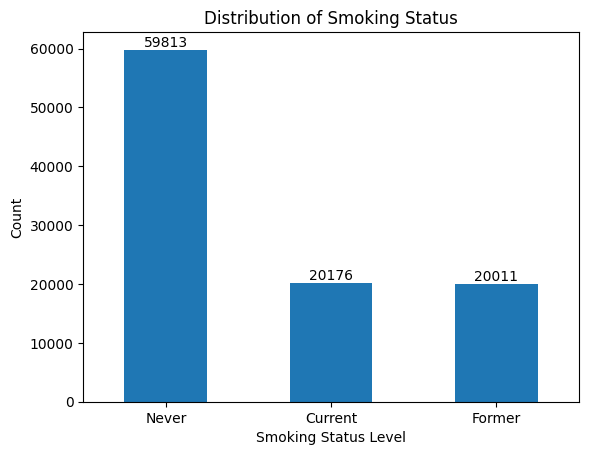

In [62]:
ax = df['smoking_status'].value_counts().plot(kind='bar')

plt.xlabel('Smoking Status Level')
plt.ylabel('Count')
plt.title('Distribution of Smoking Status')
plt.xticks(rotation = 0)

annotate_bars(ax)

plt.show()

Let's see if diabetes is more prevalent in a specific gender.

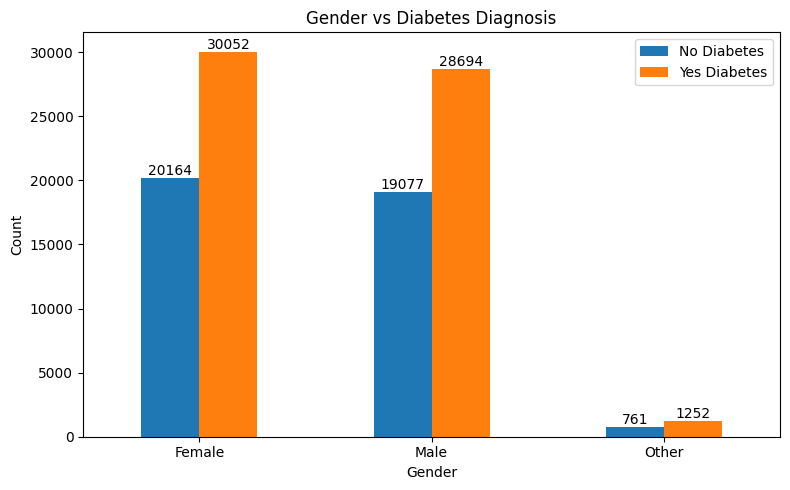

In [63]:
counts = df.groupby(['gender', 'diagnosed_diabetes']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(8,5))

counts.plot(kind='bar', ax=ax)

ax.set_title("Gender vs Diabetes Diagnosis")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(["No Diabetes", "Yes Diabetes"])

annotate_bars(ax)

plt.tight_layout()
plt.show()

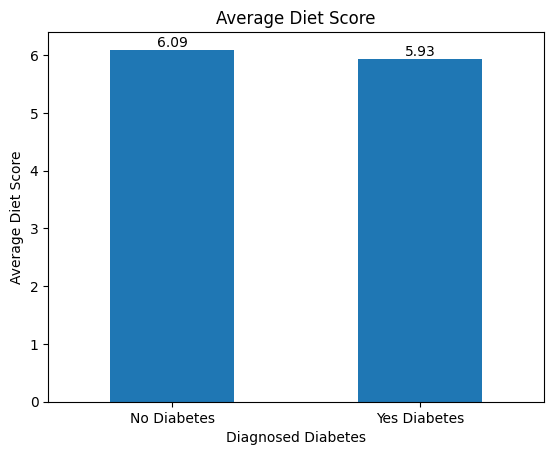

In [64]:
ax = df.groupby('diagnosed_diabetes')['diet_score'].mean().plot(kind='bar')

plt.title("Average Diet Score")
plt.xticks([0,1], ['No Diabetes', 'Yes Diabetes'], rotation=0)
plt.xlabel("Diagnosed Diabetes")
plt.ylabel("Average Diet Score")

annotate_bars(ax, fmt="{:.2f}")

plt.show()

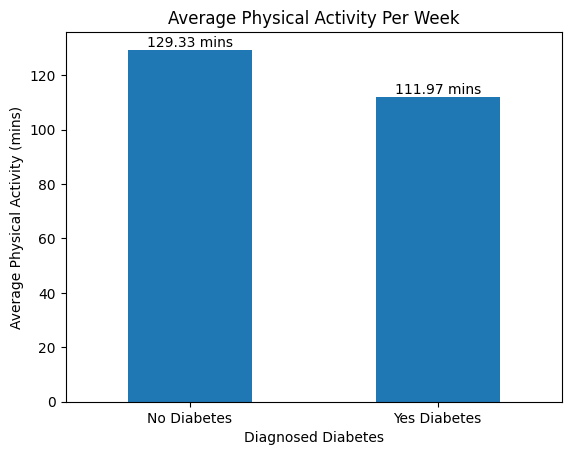

In [65]:
ax = df.groupby('diagnosed_diabetes')['physical_activity_minutes_per_week'].mean().plot(kind='bar')

plt.title("Average Physical Activity Per Week")
plt.xticks([0,1], ['No Diabetes', 'Yes Diabetes'], rotation=0)
plt.xlabel("Diagnosed Diabetes")
plt.ylabel("Average Physical Activity (mins)")

annotate_bars(ax, fmt="{:.2f} mins")

plt.show()

### Feature Selection

For this analysis, two lifestyle-related predictors were selected:

- **diet_score**
- **physical_activity_minutes_per_week**

These features were chosen because they directly support the research question: *Do lifestyle behaviors help predict diabetes diagnosis?*

The target variable, `diagnosed_diabetes`, is binary (0 = No diabetes, 1 = Diabetes).

In [66]:
X = df[['diet_score', 'physical_activity_minutes_per_week']]
y = df['diagnosed_diabetes']

In [67]:
X_withconstant = sm.add_constant(X)

In [68]:
mylogreg = sm.Logit(y, X_withconstant)

mylogreg_results = mylogreg.fit()
mylogreg_results.summary()

Optimization terminated successfully.
         Current function value: 0.666984
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     diagnosed_diabetes   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99997
Method:                           MLE   Df Model:                            2
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                0.008969
Time:                        20:10:23   Log-Likelihood:                -66698.
converged:                       True   LL-Null:                       -67302.
Covariance Type:            nonrobust   LLR p-value:                7.168e-263
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                  1.0077      0.025     40.516      0.000       0.959       1.056
diet_score                            -0.0517      0.004    -14.148      0.000      -0.059      -0.045
physical_activity_minutes_per_week    -0.0024   7.66e-05    -31.627      0.000      -0.003      -0.002
======================================================================================================
"""

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y , test_size = 0.2, random_state = 42
)

In [70]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression Modeling

Logistic Regression is used to model the probability that an individual has diabetes based on the two selected lifestyle variables. 
Because the target is binary, logistic regression is an appropriate linear classification method. 

The model outputs:
- **Predicted class** (0 or 1)
- **Probabilities** of diabetes
- **Coefficients**, which show how each feature increases or decreases diabetes risk
- **Odds ratios**, which translate coefficients into easier-to-interpret risk multipliers

This allows us to evaluate how strongly diet and physical activity contribute to diabetes outcomes.

In [71]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [72]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of diabetes

accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)

print("Accuracy:{:.2f}%".format(accuracy_lr*100))
print("Precision:{:.2f}%".format(precision_lr*100))
print("Recall:{:.2f}%".format(recall_lr*100))
print("F1 Score:{:.2f}%".format(f1_lr*100))


Accuracy:60.08%
Precision:60.41%
Recall:95.88%
F1 Score:74.12%


### Interpreting Logistic Regression Coefficients

The coefficients represent how much a one-unit increase in a feature affects the log-odds of having diabetes.

To make interpretation easier, odds ratios were computed:
- An odds ratio **below 1** means the feature *reduces* the odds of diabetes.
- An odds ratio **above 1** means the feature *increases* the odds of diabetes.

Both diet score and physical activity showed odds ratios below 1, indicating that healthier lifestyle behaviors are associated with lower diabetes risk.

In [73]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coefficients)

                              Feature  Coefficient
0                          diet_score    -0.091956
1  physical_activity_minutes_per_week    -0.205025


Now lets visualize these coefficients

<Figure size 1000x600 with 0 Axes>

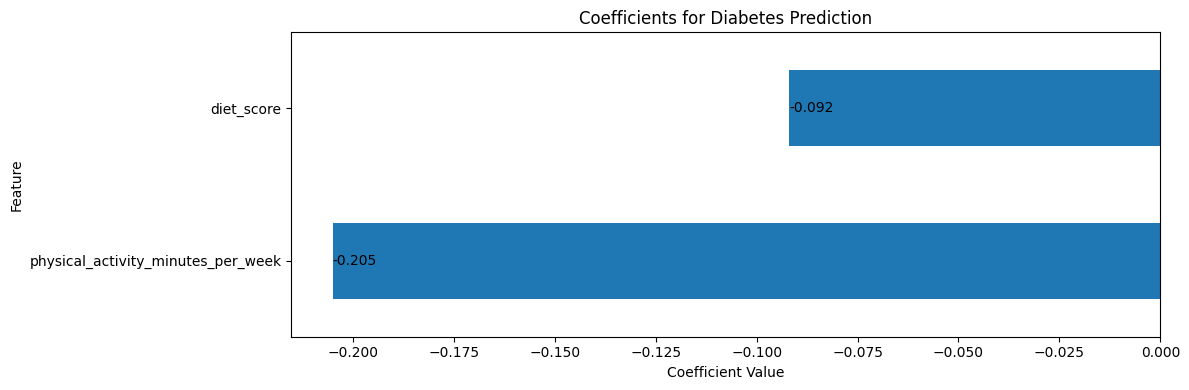

In [74]:
plt.figure(figsize=(10, 6))

coef_df = pd.DataFrame(
    data={"Coefficient": model.coef_[0]},
    index=X.columns
)

ax = coef_df.sort_values("Coefficient").plot(
    kind="barh",
    legend=False,
    title="Coefficients for Diabetes Prediction",
    figsize=(12, 4),
    grid=False,
)

ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.3f}",
        (p.get_x() + p.get_width(), p.get_y() + p.get_height() / 2),
        va='center'
    )

plt.tight_layout()
plt.show()

Lets look at the odds ratio

In [75]:
coef = model.coef_[0]
names = X.columns

odds_ratios = np.exp(coef)

for name, odd in zip(names,odds_ratios):
    print(f"Odds ratio for {name}: {odd:.3f}")

Odds ratio for diet_score: 0.912
Odds ratio for physical_activity_minutes_per_week: 0.815


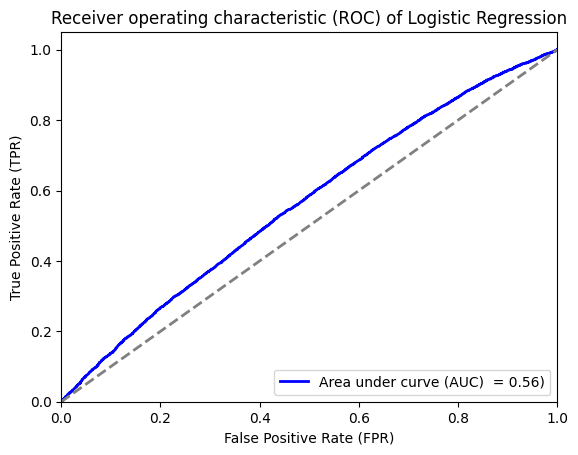

In [76]:
y_pred_sft_lr = model.predict_proba(X_test_scaled)[:,1]

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_sft_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label='Area under curve (AUC)  = %0.2f)' % roc_auc_lr)
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver operating characteristic (ROC) of Logistic Regression')
plt.legend(loc="lower right")
plt.show()

### Logistic Regression Performance

The logistic regression model achieved high recall but lower accuracy and precision. 
This means the model is very sensitive—it correctly identifies most diabetes cases—but it also produces many false positives.

This suggests that while diet and physical activity impact diabetes risk, they may not be strong enough predictors to accurately classify diabetes on their own.

In [77]:
rf = RandomForestClassifier(n_estimators=100, random_state=29)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
y_pred_rf = rf.predict(X_test)

y_pred_sft_rf = rf.predict_proba(X_test)[:,1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy:{:.2f}%".format(accuracy_rf*100))
print("Precision:{:.2f}%".format(precision_rf*100))
print("Recall:{:.2f}%".format(recall_rf*100))
print("F1 Score:{:.2f}%".format(f1_rf*100))

Accuracy:54.78%
Precision:60.42%
Recall:70.00%
F1 Score:64.86%


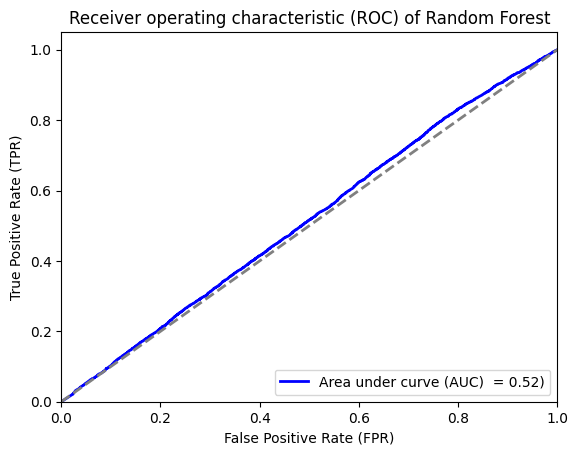

In [79]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_sft_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label='Area under curve (AUC)  = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver operating characteristic (ROC) of Random Forest')
plt.legend(loc="lower right")
plt.show()

### Random Forest Modeling

A Random Forest classifier was used to compare performance with the logistic regression model. 
Random Forests capture non-linear patterns and interactions that logistic regression may miss.

The Random Forest results showed:
- More balanced accuracy compared to logistic regression
- Lower recall, meaning it missed more true diabetes cases
- AUC slightly above random chance, indicating weak overall predictive power

These results suggest that the two selected features do not contain strong signals for determining diabetes diagnosis.

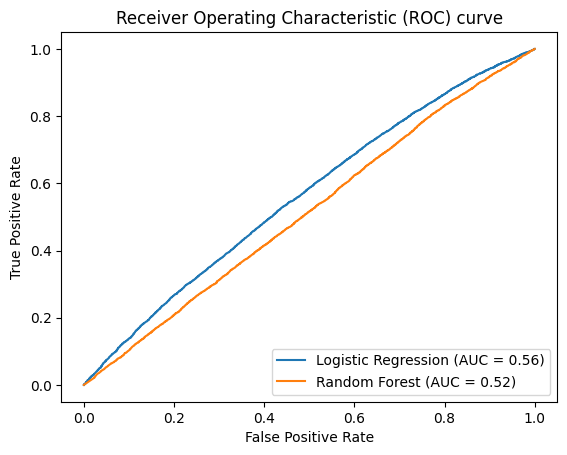

In [80]:
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.legend(loc='lower right')
plt.title('Receiver Operating Characteristic (ROC) curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

### ROC Curve Comparison

ROC curves visualize the trade-off between true positive rate and false positive rate.

- Logistic Regression AUC: **~0.56**
- Random Forest AUC: **~0.52**

An AUC of 0.50 represents random guessing, so both models perform only slightly better than chance. This confirms that using only diet score and physical activity minutes per week is not sufficient for reliable diabetes prediction.

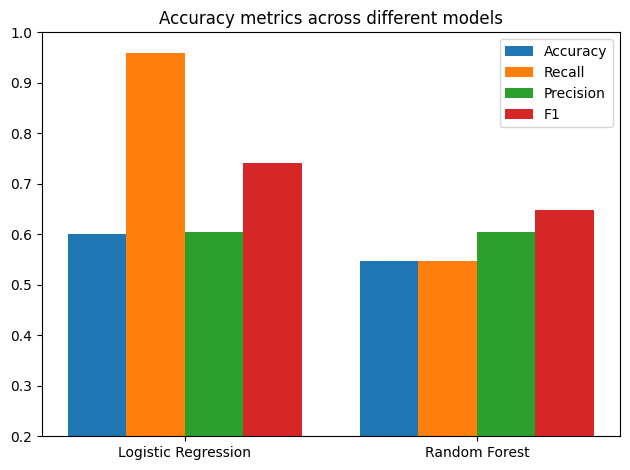

In [81]:
models = ['Logistic Regression', 'Random Forest']
accuracy = [accuracy_lr, accuracy_rf]
recall = [recall_lr, accuracy_rf]
precision = [precision_lr, precision_rf]
f1 = [f1_lr, f1_rf]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots()
rects1 = ax.bar(x - 1.5*width, accuracy, width, label='Accuracy')
rects2 = ax.bar(x - 0.5*width, recall, width, label='Recall')
rects3 = ax.bar(x + 0.5*width, precision, width, label='Precision')
rects4 = ax.bar(x + 1.5*width, f1, width, label='F1')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='upper right')
ax.set_ylim(bottom=0.20)
ax.set_ylim(top=1.00)
plt.title('Accuracy metrics across different models')

fig.tight_layout()
plt.show()

### Model Evaluation Summary

Both models show limited predictive ability based only on lifestyle behaviors.  

Key takeaways:
- Diet and physical activity are associated with diabetes but do not strongly predict it alone.
- Logistic regression captures almost all positive cases but produces many false alarms.
- Random Forest is more balanced but also not highly accurate.
- AUC values near 0.50 indicate that the features lack strong predictive power.

In conclusion, additional clinical variables would be needed to build a more reliable diabetes prediction model.